# Лабораторная 2 — Интерпретация моделей

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import xgboost as xgb
import shap

DATA_PATH = Path('walmart_features_prepared.csv')

In [ ]:
df = pd.read_csv(DATA_PATH)
df.head()

,Date,Weekly_Sales,Temperature,Fuel_Price,CPI,Unemployment,Year,Quarter,Month,WeekOfYear,...,Store_37,Store_38,Store_39,Store_40,Store_41,Store_42,Store_43,Store_44,Store_45,Holiday_Flag_1
0,2010-02-05,1.094997,-0.985693,-1.677310,0.924406,0.308601,-1.206248,1,2,-1.480973,...,False,False,False,False,False,False,False,False,False,False
1,2010-02-12,1.091856,-1.192367,-1.729689,0.928142,0.308601,-1.206248,1,2,-1.409775,...,False,False,False,False,False,False,False,False,False,True
2,2010-02-19,1.037522,-1.115137,-1.803892,0.929346,0.308601,-1.206248,1,2,-1.338578,...,False,False,False,False,False,False,False,False,False,False
3,2010-02-26,0.671108,-0.750738,-1.701317,0.930127,0.308601,-1.206248,1,2,-1.267380,...,False,False,False,False,False,False,False,False,False,False
4,2010-03-05,0.933958,-0.757808,-1.561640,0.930909,0.308601,-1.206248,1,3,-1.196183,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
raw_df = pd.read_csv('Walmart.csv')
sales_mean = raw_df['Weekly_Sales'].mean()
sales_std = raw_df['Weekly_Sales'].std()
print(f"Weekly_Sales mean (raw): {sales_mean:,.2f}")
print(f"Weekly_Sales std (raw):  {sales_std:,.2f}")

def to_original(z_values):
    return z_values * sales_std + sales_mean


Weekly_Sales mean (raw): 1,046,964.88
Weekly_Sales std (raw):  564,366.62


In [ ]:
X = df.drop(columns=['Weekly_Sales', 'Date'])
y = df['Weekly_Sales']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, shuffle=True
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True
)
X_train.shape, X_val.shape, X_test.shape


((3550, 68), (1183, 68), (1184, 68))

In [ ]:

def calc_metrics(y_true, y_pred):
    try:
        rmse = mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return {
        'RMSE': rmse,
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
    }

def calc_metrics_original(y_true_z, y_pred_z):
    return calc_metrics(to_original(y_true_z), to_original(y_pred_z))

def format_metrics(title, metrics):
    print(title)
    print(f"RMSE: {metrics['RMSE']:.2f}")
    print(f"MAE:  {metrics['MAE']:.2f}")
    print(f"R²:   {metrics['R2']:.4f}\n")


In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)

xgb_pred_train = xgb_model.predict(X_train)
xgb_pred_val = xgb_model.predict(X_val)
xgb_pred_test = xgb_model.predict(X_test)

xgb_metrics_train = calc_metrics(y_train, xgb_pred_train)
xgb_metrics_val = calc_metrics(y_val, xgb_pred_val)
xgb_metrics_test = calc_metrics(y_test, xgb_pred_test)

xgb_metrics_train_orig = calc_metrics_original(y_train, xgb_pred_train)
xgb_metrics_val_orig = calc_metrics_original(y_val, xgb_pred_val)
xgb_metrics_test_orig = calc_metrics_original(y_test, xgb_pred_test)

# print('--- Масштабированные (z-score) метрики ---')
# format_metrics('TRAIN (XGBoost):', xgb_metrics_train)
# format_metrics('VALIDATION (XGBoost):', xgb_metrics_val)
# format_metrics('TEST (XGBoost):', xgb_metrics_test)

print('--- В исходных единицах продаж ---')
format_metrics('TRAIN (XGBoost):', xgb_metrics_train_orig)
format_metrics('VALIDATION (XGBoost):', xgb_metrics_val_orig)
format_metrics('TEST (XGBoost):', xgb_metrics_test_orig)


--- В исходных единицах продаж ---
TRAIN (XGBoost):
RMSE: 15617.89
MAE:  11697.98
R²:   0.9992

VALIDATION (XGBoost):
RMSE: 63693.40
MAE:  40271.58
R²:   0.9874

TEST (XGBoost):
RMSE: 65956.94
MAE:  40839.59
R²:   0.9870



In [ ]:
xgb_importance = (
    pd.DataFrame({'feature': X.columns, 'importance': xgb_model.feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
xgb_importance.head(20)


,feature,importance
0,Store_Weekly_Sales_mean,0.802360
1,Store_Weekly_Sales_median,0.078617
2,Weekly_Sales_lag_1,0.061361
3,Weekly_Sales_roll_mean_4,0.009906
4,WeekOfYear,0.006445
5,Weekly_Sales_lag_2,0.006147
6,Weekly_Sales_lag_4,0.003578
7,Holiday_Flag_1,0.002865
8,Holiday_Flag_numeric,0.002504
9,Month,0.002288


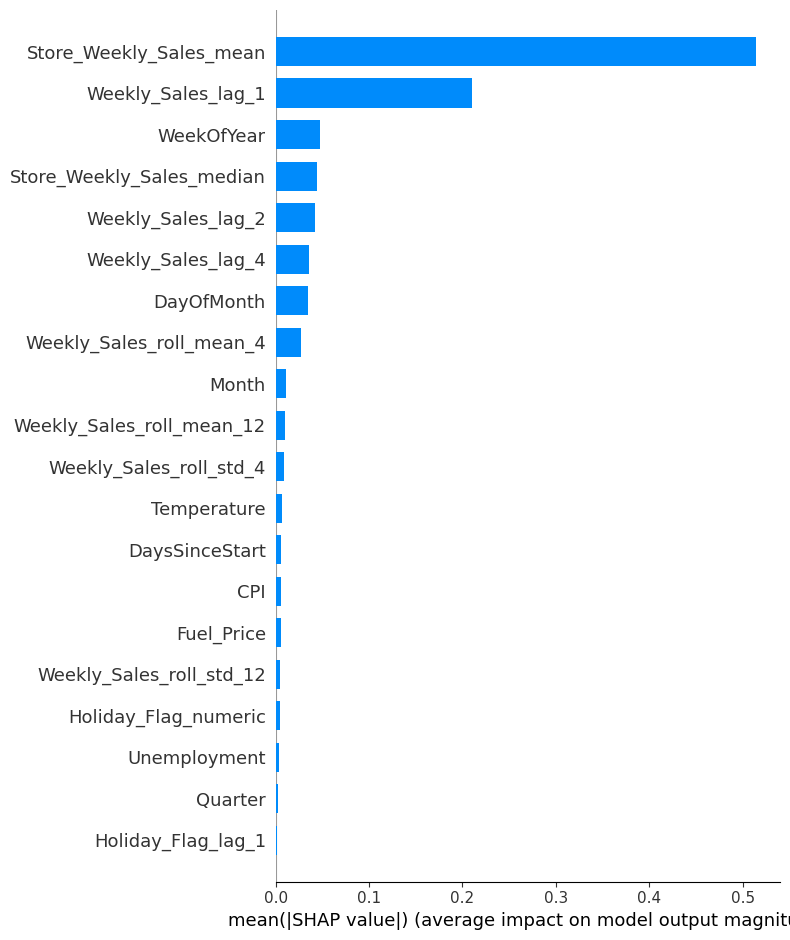

In [ ]:
X_sample = X_train.sample(n=min(500, len(X_train)), random_state=42)
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_sample)

if isinstance(shap_values_xgb, list):
    shap_values_xgb = shap_values_xgb[0]

shap.summary_plot(shap_values_xgb, X_sample, plot_type='bar')


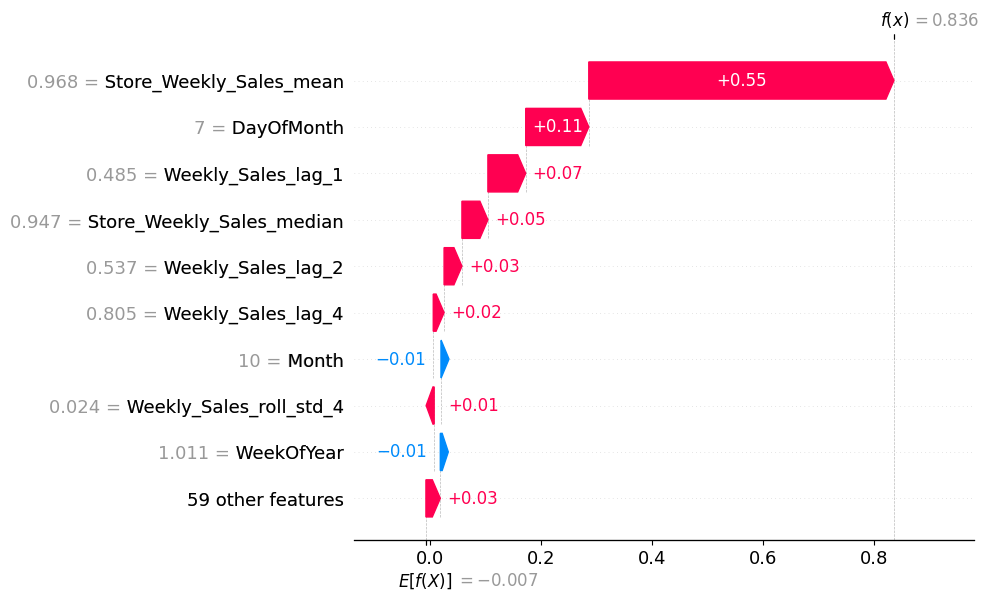

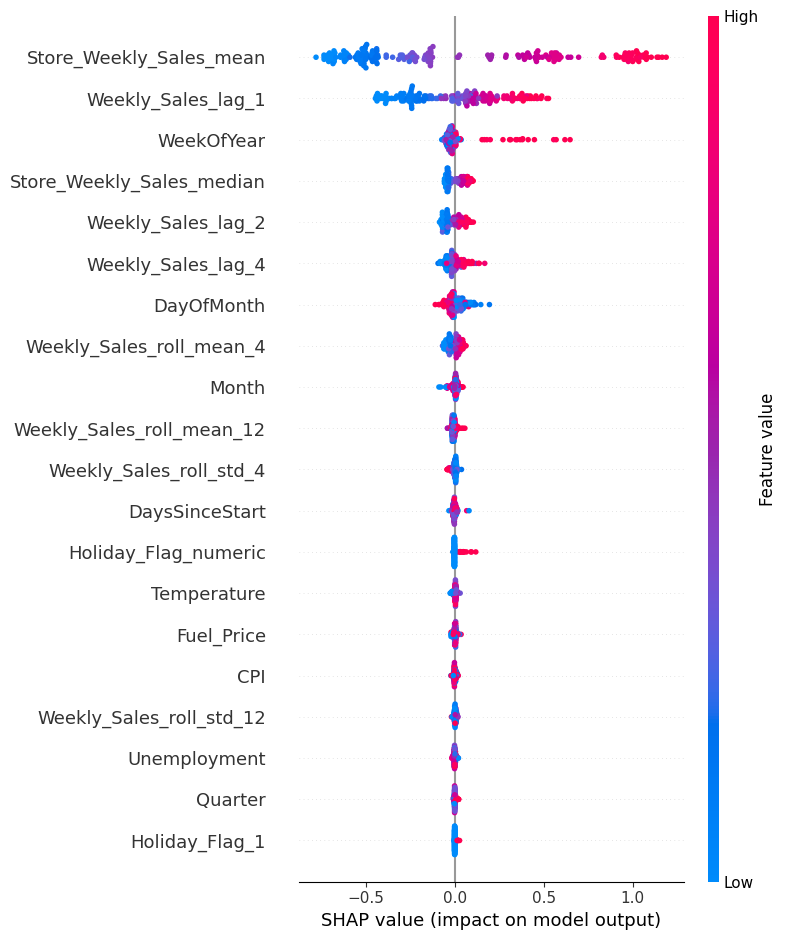

In [ ]:
import shap
shap.initjs()

X_test_sample = X_test.iloc[:200]
explainer_xgb2 = shap.Explainer(xgb_model)
shap_values_xgb2 = explainer_xgb2(X_test_sample)

shap_values_xgb2
shap.plots.waterfall(shap_values_xgb2[0])
shap.summary_plot(shap_values_xgb2, X_test_sample)


In [ ]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)

rf_pred_train = rf.predict(X_train)
rf_pred_val = rf.predict(X_val)
rf_pred_test = rf.predict(X_test)

rf_metrics_train = calc_metrics(y_train, rf_pred_train)
rf_metrics_val = calc_metrics(y_val, rf_pred_val)
rf_metrics_test = calc_metrics(y_test, rf_pred_test)

rf_metrics_train_orig = calc_metrics_original(y_train, rf_pred_train)
rf_metrics_val_orig = calc_metrics_original(y_val, rf_pred_val)
rf_metrics_test_orig = calc_metrics_original(y_test, rf_pred_test)

# print('--- Масштабированные (z-score) метрики ---')
# format_metrics('TRAIN (Random Forest):', rf_metrics_train)
# format_metrics('VALIDATION (Random Forest):', rf_metrics_val)
# format_metrics('TEST (Random Forest):', rf_metrics_test)

print('--- В исходных единицах продаж ---')
format_metrics('TRAIN (Random Forest):', rf_metrics_train_orig)
format_metrics('VALIDATION (Random Forest):', rf_metrics_val_orig)
format_metrics('TEST (Random Forest):', rf_metrics_test_orig)


--- В исходных единицах продаж ---
TRAIN (Random Forest):
RMSE: 36706.17
MAE:  21030.16
R²:   0.9957

VALIDATION (Random Forest):
RMSE: 81460.72
MAE:  50664.45
R²:   0.9794

TEST (Random Forest):
RMSE: 86600.31
MAE:  51911.17
R²:   0.9776



In [ ]:
rf_importance = (
    pd.DataFrame({'feature': X.columns, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
rf_importance.head(20)


,feature,importance
0,Store_Weekly_Sales_median,0.345822
1,Store_Weekly_Sales_mean,0.336994
2,Weekly_Sales_lag_1,0.245505
3,Weekly_Sales_roll_mean_4,0.028557
4,WeekOfYear,0.011035
5,Weekly_Sales_lag_4,0.008748
6,Weekly_Sales_lag_2,0.005490
7,DayOfMonth,0.005455
8,Weekly_Sales_roll_mean_12,0.002256
9,Weekly_Sales_roll_std_4,0.001767


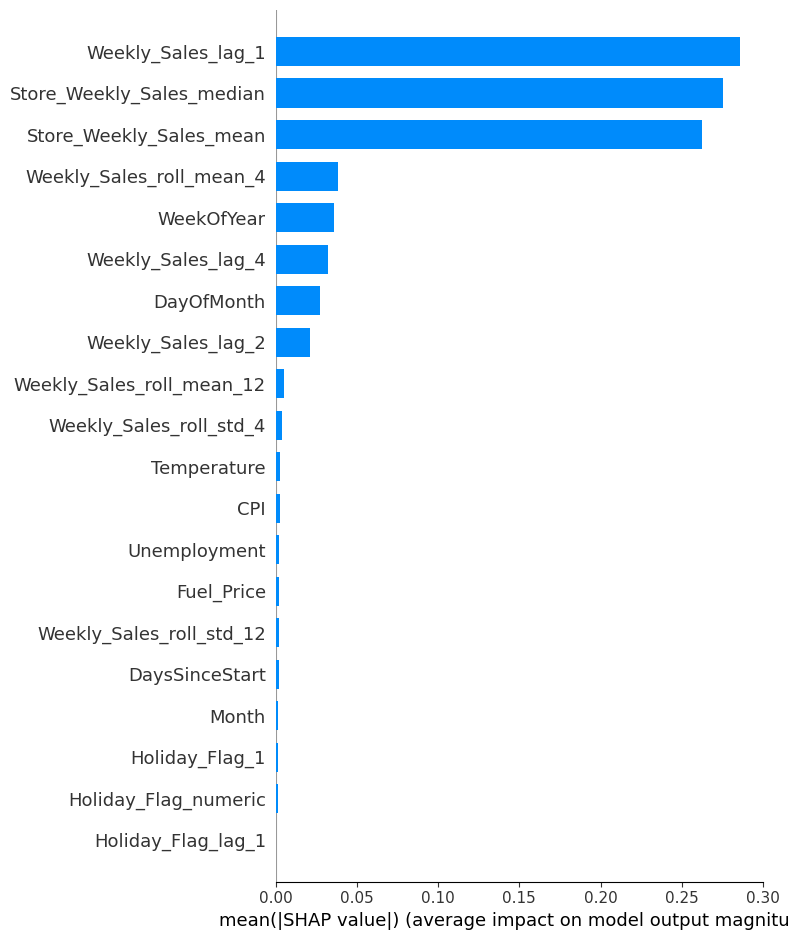

In [ ]:
X_sample = X_train.sample(n=min(500, len(X_train)), random_state=42)
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_sample)

if isinstance(shap_values_rf, list):
    shap_values_rf = shap_values_rf[0]

shap.summary_plot(shap_values_rf, X_sample, plot_type='bar')


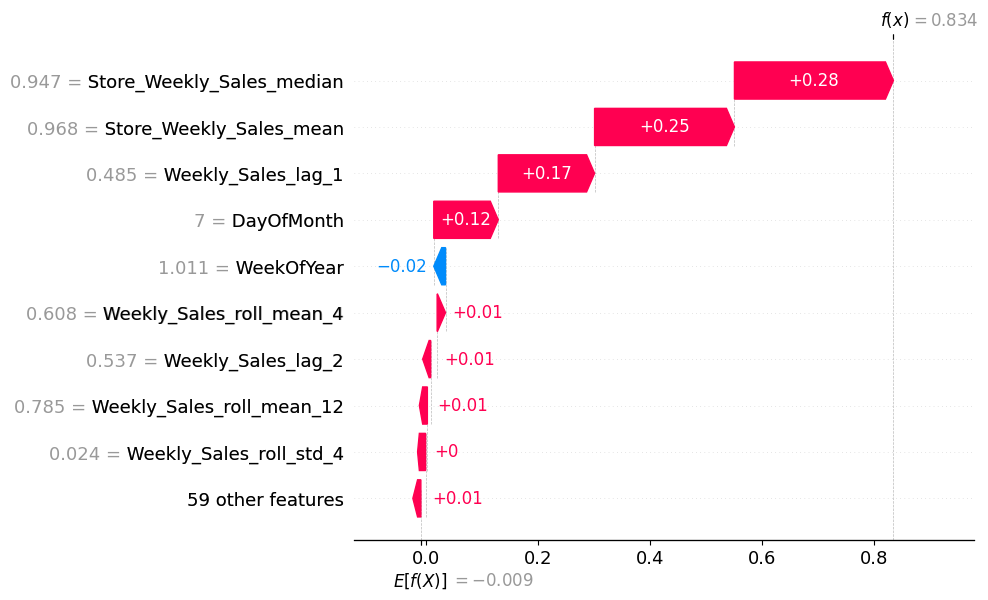

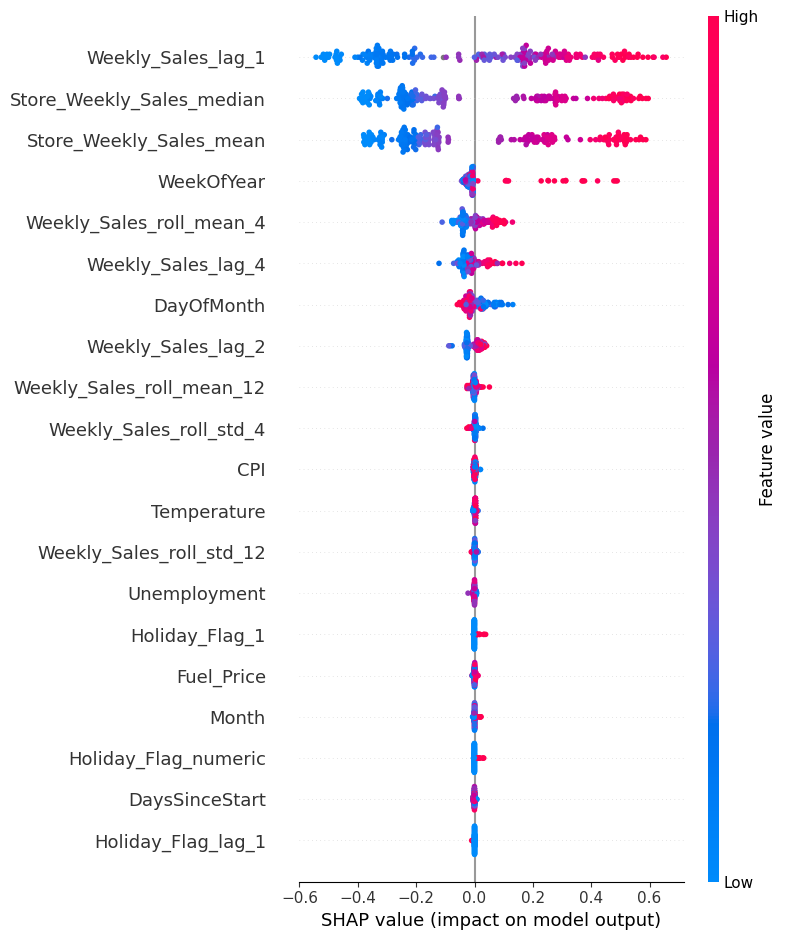

In [ ]:
import shap
shap.initjs()

X_test_sample = X_test.iloc[:200]
explainer = shap.Explainer(rf)
shap_values = explainer(X_test_sample)

shap_values
shap.plots.waterfall(shap_values[0])
shap.summary_plot(shap_values, X_test_sample)
